In [26]:
import pandas as pd
import numpy as np
import json
import re
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import LinearSVC

In [27]:
# Load Data

def load_json_file(path):
    data = []
    with open(path, 'r') as f:
        content = f.read().strip()

        objects = content.split('}\n{')

        for obj in objects:
            if not obj.startswith('{'):
                obj = '{' + obj
            if not obj.endswith('}'):
                obj = obj + '}'

            try:
                data.append(json.loads(obj))
            except:
                continue

    return pd.DataFrame(data)

train = load_json_file('train.json')
test = load_json_file('test.json')

print("Train shape:", train.shape)
train.head()

Train shape: (4374, 5)


,text,date,label,id,label_name
0,The {@Clinton LumberKings@} beat the {@Cedar R...,2019-09-08,4,1170516324419866624,sports_&_gaming
1,I would rather hear Eli Gold announce this Aub...,2019-09-08,4,1170516440690176006,sports_&_gaming
2,"Someone take my phone away, I’m trying to not ...",2019-09-08,4,1170516543387709440,sports_&_gaming
3,"A year ago, Louisville struggled to beat an FC...",2019-09-08,4,1170516620466429953,sports_&_gaming
4,Anyone know why the #Dodgers #Orioles game nex...,2019-09-08,4,1170516711411310592,sports_&_gaming


In [39]:
label_mapping = dict(zip(train['label'], train['label_name']))

label_mapping

{4: 'sports_&_gaming',
 2: 'pop_culture',
 3: 'daily_life',
 1: 'business_&_entrepreneurs',
 5: 'science_&_technology',
 0: 'arts_&_culture'}

In [40]:
#Cek Data

print(train.columns)
print(train.isnull().sum())

Index(['text', 'date', 'label', 'id', 'label_name', 'clean_text',
       'text_length'],
      dtype='str')
text           0
date           0
label          0
id             0
label_name     0
clean_text     0
text_length    0
dtype: int64


In [41]:
# Cleaning function

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\{\{.*?\}\}", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [42]:
# Apply Cleaning 

train['clean_text'] = train['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)

train[['text', 'clean_text']].head()

,text,clean_text
0,The {@Clinton LumberKings@} beat the {@Cedar R...,the clinton lumberkings beat the cedar rapids ...
1,I would rather hear Eli Gold announce this Aub...,i would rather hear eli gold announce this aub...
2,"Someone take my phone away, I’m trying to not ...",someone take my phone away im trying to not lo...
3,"A year ago, Louisville struggled to beat an FC...",a year ago louisville struggled to beat an fcs...
4,Anyone know why the #Dodgers #Orioles game nex...,anyone know why the dodgers orioles game next ...


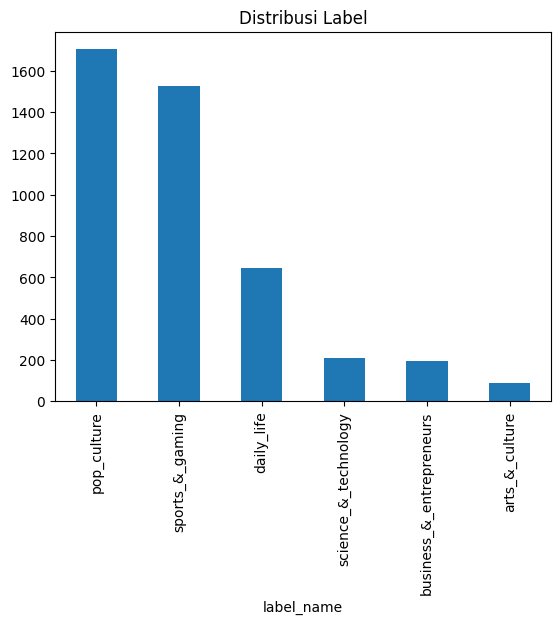

In [43]:
#Distribusi Label

train['label_name'].value_counts().plot(kind='bar')
plt.title("Distribusi Label")
plt.show()

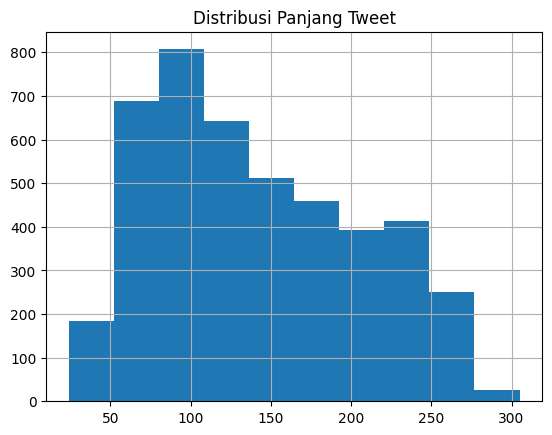

In [44]:
#Text Length

train['text_length'] = train['clean_text'].apply(len)

train['text_length'].hist()
plt.title("Distribusi Panjang Tweet")
plt.show()

In [45]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=8000,
    stop_words='english',
    ngram_range=(1,2)
)

X = tfidf.fit_transform(train['clean_text'])
y = train['label']

print("Shape TF-IDF:", X.shape)

Shape TF-IDF: (4374, 8000)


In [46]:
# Split Data

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
#Train Model
model = LinearSVC()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [47]:
# Evaluate Model

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

Accuracy: 0.8137142857142857

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.13      0.24        15
           1       0.61      0.43      0.51        44
           2       0.82      0.92      0.86       333
           3       0.68      0.55      0.61       132
           4       0.88      0.95      0.91       309
           5       0.72      0.50      0.59        42

    accuracy                           0.81       875
   macro avg       0.79      0.58      0.62       875
weighted avg       0.81      0.81      0.80       875



In [49]:
# Save Data

joblib.dump(model, 'model.pkl')
joblib.dump(tfidf, 'tfidf.pkl')

['tfidf.pkl']

In [48]:
joblib.dump(label_mapping, 'label_mapping.pkl')

['label_mapping.pkl']